# Chapter 33: Technical Debt as a Stock

*Systems Thinking with AI* by Jason Karpeles

Debt is a stock nobody can count, and the review window decides which policy looks wise.

**Goal.** Four runs of the chapter's delivery team. Move the review date and watch the lead change hands, compare nominal and available capacity, read the share of capacity going to rework before delivery volume shows anything, and test whether the repayment conclusion survives the range of the drag coefficient nobody has measured.

**Demonstrations**

1. The review window picks the winner
2. Capacity is not what the plan says
3. Rework share moves before delivery does
4. Test the conclusion against the proxy's range

The chapter's own model code is written out in full below, so the notebook runs with NumPy and Matplotlib alone. The interactive version of this chapter is at [https://karpeles.com/companions/systems-thinking-with-ai/33-technical-debt/reader.html](https://karpeles.com/companions/systems-thinking-with-ai/33-technical-debt/reader.html).

All example inputs are constructed teaching examples built from the chapter's own numbers.

## Setup

Imports, plus two small helpers: `%%module` runs a cell as a named module so the chapter files can import one another by their package names, and `show` draws a demonstration's figure and lists its values.

In [1]:
import os, sys, tempfile, types
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.core.magic import register_cell_magic
from IPython.display import Markdown, display

%matplotlib inline

WORKDIR = tempfile.mkdtemp(prefix="systems-thinking-")


@register_cell_magic
def module(line, cell):
    """Run a cell as a named module so the chapter code can import it by name."""
    name = line.strip()
    parts = name.split(".")
    for i in range(1, len(parts)):
        parent = ".".join(parts[:i])
        if parent not in sys.modules:
            pkg = types.ModuleType(parent)
            pkg.__path__ = []
            sys.modules[parent] = pkg
            if i > 1:
                setattr(sys.modules[".".join(parts[:i - 1])], parts[i - 1], pkg)
    mod = types.ModuleType(name)
    mod.__file__ = os.path.join(WORKDIR, *parts) + ".py"
    mod.__package__ = ".".join(parts[:-1])
    sys.modules[name] = mod
    if len(parts) > 1:
        setattr(sys.modules[".".join(parts[:-1])], parts[-1], mod)
    exec(compile(cell, name, "exec"), mod.__dict__)


def show(result):
    """Draw the figure, then list the calculated values and the reading."""
    fig, metrics, interpretation = result[:3]
    plt.show()
    display(Markdown("\n".join(f"- **{k}:** {v}" for k, v in metrics.items())))
    display(Markdown(interpretation))


def sweep(function, controls):
    """Recompute every setting offered in the interactive reader and list the values."""
    import itertools
    keys = [k for k, _ in controls]
    rows = []
    for combo in itertools.product(*[v for _, v in controls]):
        fig, metrics, _ = function(**dict(zip(keys, combo)))[:3]
        plt.close(fig)
        setting = ", ".join(f"{k} = {v}" for k, v in zip(keys, combo))
        rows.append(f"- **{setting}**: " + "; ".join(f"{k} {v}" for k, v in metrics.items()))
    display(Markdown("\n".join(rows)))


## The chapter's model code

Each cell below is one file of the chapter's code, defined under its package name. Later chapters build on earlier ones, so some files come from the chapters they cite.

`chapters/chapter_33_technical_debt/code/debt.py`

In [2]:
%%module chapters.chapter_33_technical_debt.code.debt
"""Shortcuts, defects, rework, and the productivity they consume."""

from dataclasses import dataclass


@dataclass
class State:
    """Delivery, debt, defects, and morale at one moment."""
    features_done: float = 0.0
    debt: float = 0.0            # shortcuts taken and not repaid
    defects: float = 0.0         # discovered and not yet fixed
    morale: float = 1.0


@dataclass(frozen=True)
class Policy:
    """Capacity, pressure, and the share reserved for repayment."""
    capacity: float = 10.0            # engineer-weeks available per period
    feature_pressure: float = 1.0     # 0 to 1, how hard delivery is pushed
    repayment_share: float = 0.0      # fraction of capacity reserved for paying debt
    shortcut_rate: float = 0.5        # debt created per unit of pressure per feature
    defect_rate: float = 0.08         # defects surfacing per unit of debt per period
    rework_cost: float = 0.6          # capacity consumed per defect fixed
    drag: float = 0.02                # capacity lost per unit of debt


def available_capacity(state: State, policy: Policy) -> float:
    """What is left after debt drag and morale. The quantity nobody measures."""
    drag = policy.drag * state.debt
    return max(0.0, (policy.capacity - drag) * state.morale)


def step(state: State, policy: Policy, dt: float = 1.0) -> State:
    """One period: deliver, accrue debt, surface defects, move morale."""
    usable = available_capacity(state, policy)
    to_repay = usable * policy.repayment_share
    to_deliver = usable - to_repay

    fixing = min(state.defects, to_deliver / policy.rework_cost)
    feature_capacity = max(0.0, to_deliver - fixing * policy.rework_cost)
    delivered = feature_capacity * policy.feature_pressure
    new_debt = delivered * policy.shortcut_rate * policy.feature_pressure
    repaid = min(state.debt, to_repay)
    surfacing = policy.defect_rate * state.debt

    morale_target = 1.0 - min(0.6, 0.02 * state.defects)
    return State(
        features_done=state.features_done + dt * delivered,
        debt=max(0.0, state.debt + dt * (new_debt - repaid)),
        defects=max(0.0, state.defects + dt * (surfacing - fixing)),
        morale=min(1.0, max(0.2, state.morale + dt * (morale_target - state.morale) / 4.0)),
    )


def run(policy: Policy, periods: int = 60, start: State | None = None) -> list[State]:
    """Advance the team and return every period's state."""
    state = start or State()
    path = [state]
    for _ in range(periods):
        state = step(state, policy)
        path.append(state)
    return path


def summary(path: list[State], policy: Policy) -> dict[str, float]:
    """The few numbers a reader should carry out of a run."""
    early = path[12].features_done
    return {
        "features_by_12": early,
        "features_total": path[-1].features_done,
        "final_debt": path[-1].debt,
        "peak_defects": max(s.defects for s in path),
        "final_capacity": available_capacity(path[-1], policy),
    }


def observable_measures() -> dict[str, str]:
    """What can be counted, and what has to stay a proxy."""
    return {
        "defects": "observable: a defect tracker counts them",
        "rework_time": "observable: time booked against fixes, if it is booked honestly",
        "features_done": "observable: shipped items",
        "debt": "PROXY: nobody can count shortcuts. Inferred from drag, or estimated by the team",
        "morale": "PROXY: surveys measure something correlated, on a different clock",
    }


Formatting and plotting helpers used by the demonstrations (`readerkit`).

In [3]:
%%module readerkit
"""Formatting and plotting helpers shared by the demonstrations."""
from __future__ import annotations

import math

# Restrained palette with good contrast on white. Use direct labels, not
# colour alone, to distinguish series.
PALETTE = {
    "ink": "#172a3b",
    "teal": "#136f75",
    "gold": "#8f5d0f",
    "navy": "#334c72",
    "terracotta": "#a24a33",
    "olive": "#5d6a37",
    "grey": "#6b757b",
    "light": "#c9d3d6",
}

FONT_SIZE = 11.5
SMALL_FONT = 10.5


def new_figure(ncols=1, width=None, height=4.3):
    """Return (fig, axes) with constrained layout and the house size.

    One panel is 6.6 x 4.3 inches; two panels are 10.4 x 4.3 inches. At the
    reader's display width this keeps 11 to 12 point text legible.
    """
    import matplotlib.pyplot as plt

    if width is None:
        width = 6.6 if ncols == 1 else 10.4
    fig, axes = plt.subplots(1, ncols, figsize=(width, height), layout="constrained")
    for ax in (axes if ncols > 1 else [axes]):
        ax.grid(alpha=0.18)
    return fig, axes


def fmt(value, digits=2):
    """Format a finite number with a fixed number of decimals.

    Returns the string "undefined" for None. Raises ValueError for NaN or
    infinity, because a reader must be told why a value is undefined; use
    ``undefined(reason)`` for that.
    """
    if value is None:
        return "undefined"
    value = float(value)
    if not math.isfinite(value):
        raise ValueError("non-finite value; state why it is undefined with undefined(reason)")
    text = f"{value:.{digits}f}"
    if text.startswith("-") and float(text) == 0:
        text = text[1:]
    return text


def signed(value, digits=2):
    """Format a number for use inside a written calculation: negatives get parentheses."""
    text = fmt(value, digits)
    return f"({text})" if text.startswith("-") else text


def undefined(reason):
    """Display string for a quantity that has no value in this state."""
    return f"undefined ({reason})"


def is_tie(a, b, tol=1e-9):
    return abs(float(a) - float(b)) <= tol


def argmax_set(scores, tol=1e-9):
    """Names whose score is within tol of the maximum. ``scores`` is a dict."""
    best = max(scores.values())
    return [name for name, value in scores.items() if abs(value - best) <= tol]


def label_point(ax, x, y, text, color=None, dx=6, dy=6, ha="left", va="bottom", size=None):
    """Directly label a point with an offset in points (no arrow)."""
    return ax.annotate(
        text,
        (x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        ha=ha,
        va=va,
        color=color or PALETTE["ink"],
        fontsize=size or SMALL_FONT,
    )


## Demonstration functions

Each function below runs the chapter's model for one demonstration and returns a figure, the calculated values and a worked reading of them.

In [4]:
"""Chapter 33 reader: technical debt as a stock.

Every number comes from the Chapter 33 pack (Policy, State, run, summary, available_capacity, step)
so the reader, the pack and the book agree.
"""
from __future__ import annotations

import numpy as np
from readerkit import PALETTE, fmt, new_figure, signed

from chapters.chapter_33_technical_debt.code.debt import (
    Policy,
    State,
    available_capacity,
    run,
    step,
    summary,
)

EQ_DRAG = "drag = policy.drag * state.debt"
EQ_CAP = "return max(0.0, (policy.capacity - drag) * state.morale)"

HORIZON = 60


def tag(ax, text, color, row=0, x=0.97, y=0.96):
    """A label in an empty corner of a panel, on a white box so no line shows through."""
    ax.text(x, y - 0.095 * row, text, transform=ax.transAxes, ha="right", va="top", color=color,
            fontsize=10.5, bbox=dict(facecolor="white", edgecolor="none", alpha=0.92, pad=1.5))


# Demonstration 1: the review window decides which policy looks better.

def review_window(review_period=12, repayment_share=0.2):
    push = Policy()
    repay = Policy(repayment_share=repayment_share)
    a = run(push, HORIZON)
    b = run(repay, HORIZON)
    periods = np.arange(0, HORIZON + 1)
    fa = [s.features_done for s in a]
    fb = [s.features_done for s in b]
    at_a, at_b = fa[review_period], fb[review_period]

    fig, ax = new_figure()
    ax.plot(periods, fa, color=PALETTE["terracotta"])
    ax.plot(periods, fb, color=PALETTE["teal"])
    ax.axvline(review_period, color=PALETTE["grey"], linestyle="dashed", linewidth=1.3)
    ax.set_xlim(0, HORIZON)
    ax.set_ylim(0, max(fa[-1], fb[-1]) * 1.45)
    tag(ax, "Terracotta: push hard", PALETTE["terracotta"], row=0, x=0.45, y=0.96)
    tag(ax, f"Teal: push, repay {fmt(repayment_share * 100, 0)}%", PALETTE["teal"], row=1, x=0.45, y=0.96)
    tag(ax, f"Dashed: review at period {review_period}", PALETTE["grey"], row=2, x=0.45, y=0.96)
    ax.set_xlabel("Period")
    ax.set_ylabel("Features delivered (cumulative)")

    gap = at_b - at_a
    if abs(gap) < 0.05:
        verdict = "The two policies tie at this review to one decimal."
    elif gap > 0:
        verdict = "At this review the repaying policy looks better."
    else:
        verdict = "At this review push hard looks better, and a short window would confirm it."
    base = at_a if gap <= 0 else at_b
    ratio_text = (f"{fmt(max(at_a, at_b), 1)} / {fmt(min(at_a, at_b), 1)} = "
                  f"{fmt(max(at_a, at_b) / min(at_a, at_b), 3)}") if min(at_a, at_b) > 0 else "undefined (no features yet)"
    metrics = {
        "Review at period": str(review_period),
        "Push hard, features": fmt(at_a, 1),
        f"Repay {fmt(repayment_share * 100, 0)}%, features": fmt(at_b, 1),
        "Repaying minus push hard": signed(round(at_b, 1) - round(at_a, 1), 1),
        "Debt under push hard": fmt(a[review_period].debt, 1),
    }
    interpretation = (
        f"At period {review_period}: {fmt(at_b, 1)} - {fmt(at_a, 1)} = {signed(gap, 1)} features for the "
        f"repaying policy. The larger total over the smaller is {ratio_text}. {verdict}"
    )
    alt = (
        f"Cumulative features over 60 periods for push hard and for repaying {fmt(repayment_share * 100, 0)} "
        f"percent, with a dashed line at the review in period {review_period}, where the totals are "
        f"{fmt(at_a, 1)} and {fmt(at_b, 1)}."
    )
    return fig, metrics, interpretation, alt


# Demonstration 2: nominal capacity is not available capacity.

def capacity_gap(situation="after a year", drag=0.02):
    path = run(Policy(), HORIZON)
    index = {"fresh": 0, "after a quarter": 12, "after a year": HORIZON}[situation]
    state = path[index]
    policy = Policy(drag=drag)
    available = available_capacity(state, policy)
    nominal = policy.capacity
    drag_loss = drag * state.debt
    after_drag = max(0.0, nominal - drag_loss)

    fig, ax = new_figure()
    labels = ["Nominal", "After debt drag", "Available"]
    values = [nominal, after_drag, available]
    colors = [PALETTE["light"], PALETTE["navy"], PALETTE["teal"]]
    ax.bar(labels, values, color=colors)
    for x, v in enumerate(values):
        ax.annotate(fmt(v, 2), (x, v), xytext=(0, 4), textcoords="offset points", ha="center", fontsize=10.5)
    ax.set_ylim(0, 12.5)
    ax.set_xlabel("Step from the plan to what exists")
    ax.set_ylabel("Capacity (engineer-weeks per period)")

    if available > 0:
        over = nominal / available
        over_text = f"{fmt(nominal, 1)} / {fmt(available, 2)} = {fmt(over, 2)}"
        verdict = f"A plan built on nominal capacity assumes {fmt(over, 2)} times what exists."
    else:
        over_text = "undefined (available capacity is zero)"
        verdict = "Nothing is available, so the ratio to the plan is undefined."
    metrics = {
        "Debt carried": fmt(state.debt, 1),
        "Morale": fmt(state.morale, 2),
        "Drag coefficient": fmt(drag, 3),
        "Available capacity": fmt(available, 2),
        "Plan over reality": fmt(nominal / available, 2) if available > 0 else "undefined (available capacity is zero)",
    }
    interpretation = (
        f"Drag = {fmt(drag, 3)} x {fmt(state.debt, 1)} = {fmt(drag_loss, 2)}. Available = max(0, "
        f"({fmt(nominal, 1)} - {fmt(drag_loss, 2)}) x {fmt(state.morale, 4)}) = {fmt(available, 2)}. "
        f"Plan over reality = {over_text}. {verdict}"
    )
    alt = (
        f"Three bars: nominal capacity {fmt(nominal, 1)}, capacity after debt drag {fmt(after_drag, 2)}, and "
        f"available capacity after morale {fmt(available, 2)}."
    )
    return fig, metrics, interpretation, alt


# Demonstration 3: the leading indicator, the share of capacity spent on rework.

def rework_signal(repayment_share=0.0, period=12):
    policy = Policy(repayment_share=repayment_share)
    path = run(policy, HORIZON)
    rework_share = []
    delivered = []
    for before, after in zip(path[:-1], path[1:]):
        usable = available_capacity(before, policy)
        deliver_cap = usable - usable * policy.repayment_share
        fixing = min(before.defects, deliver_cap / policy.rework_cost)
        rework_share.append(fixing * policy.rework_cost / usable if usable > 0 else 0.0)
        delivered.append(after.features_done - before.features_done)
    periods = np.arange(1, HORIZON + 1)

    fig, (left, right) = new_figure(ncols=2)
    left.plot(periods, np.array(rework_share) * 100, color=PALETTE["terracotta"])
    left.axhline(100, color=PALETTE["light"], linewidth=1.0)
    left.axvline(period, color=PALETTE["grey"], linestyle="dashed", linewidth=1.2)
    left.set_xlim(1, HORIZON)
    left.set_ylim(0, 135)
    tag(left, "Share of capacity spent on rework", PALETTE["terracotta"], row=0, x=0.97, y=0.96)
    left.set_xlabel("Period")
    left.set_ylabel("Rework share (percent of usable capacity)")
    left.set_title("The leading indicator", fontsize=11.5)

    right.plot(periods, delivered, color=PALETTE["navy"])
    right.axvline(period, color=PALETTE["grey"], linestyle="dashed", linewidth=1.2)
    right.set_xlim(1, HORIZON)
    right.set_ylim(0, 14)
    tag(right, "Features delivered per period", PALETTE["navy"], row=0, x=0.97, y=0.96)
    right.set_xlabel("Period")
    right.set_ylabel("Features per period")
    right.set_title("The number the review watches", fontsize=11.5)

    before = path[period - 1]
    usable = available_capacity(before, policy)
    to_repay = usable * policy.repayment_share
    to_deliver = usable - to_repay
    fixing = min(before.defects, to_deliver / policy.rework_cost)
    rework = fixing * policy.rework_cost
    share = rework_share[period - 1]
    metrics = {
        "Repayment share": fmt(repayment_share, 2),
        "Period read": str(period),
        "Usable capacity": fmt(usable, 2),
        "Rework share": fmt(share * 100, 1) + " percent",
        "Features delivered that period": fmt(delivered[period - 1], 2),
    }
    interpretation = (
        f"In period {period} the team starts with {fmt(before.defects, 3)} open defects and "
        f"{fmt(usable, 3)} usable capacity. After repaying {fmt(repayment_share, 2)} x {fmt(usable, 3)} = "
        f"{fmt(to_repay, 3)}, it fixes min({fmt(before.defects, 3)}, {fmt(to_deliver, 3)} / 0.6) = "
        f"{fmt(fixing, 3)} defects, spending {fmt(fixing, 3)} x 0.6 = {fmt(rework, 3)} on rework. "
        f"Rework share = {fmt(rework, 3)} / {fmt(usable, 3)} = {fmt(share, 3)}, which is "
        f"{fmt(share * 100, 1)} percent."
    )
    alt = (
        f"Left panel: the percent of usable capacity spent on rework in each of 60 periods, "
        f"{fmt(share * 100, 1)} percent in period {period}. Right panel: features delivered per period."
    )
    return fig, metrics, interpretation, alt


# Demonstration 4: does the conclusion survive the range of the unmeasured drag?

def drag_range(drag=0.02, horizon=60):
    horizon = int(horizon)
    push = Policy(drag=drag)
    repay = Policy(drag=drag, repayment_share=0.2)
    a = run(push, HORIZON)
    b = run(repay, HORIZON)
    ta, tb = a[horizon].features_done, b[horizon].features_done
    gap = tb - ta

    fig, (left, right) = new_figure(ncols=2)
    bars = left.bar(["Push hard", "Repay 20%"], [ta, tb], color=[PALETTE["terracotta"], PALETTE["teal"]])
    for x, v in enumerate([ta, tb]):
        left.annotate(fmt(v, 1), (x, v), xytext=(0, 4), textcoords="offset points", ha="center", fontsize=10.5)
    left.set_ylim(0, 400)
    left.set_xlabel(f"Policy (features at period {horizon})")
    left.set_ylabel("Features delivered")
    left.set_title("Who leads", fontsize=11.5)

    periods = np.arange(0, HORIZON + 1)
    right.plot(periods, [s.debt for s in a], color=PALETTE["terracotta"])
    right.plot(periods, [s.debt for s in b], color=PALETTE["teal"])
    right.axvline(horizon, color=PALETTE["grey"], linestyle="dashed", linewidth=1.2)
    right.set_xlim(0, HORIZON)
    right.set_ylim(0, 190)
    tag(right, "Push hard", PALETTE["terracotta"], row=0, x=0.40)
    tag(right, "Repay 20%", PALETTE["teal"], row=1, x=0.40)
    right.set_xlabel("Period")
    right.set_ylabel("Debt (a proxy, shown as a direction)")
    right.set_title("The stock nobody can count", fontsize=11.5)

    if abs(gap) < 0.05:
        verdict = "The policies tie to one decimal at this horizon."
    elif gap > 0:
        verdict = "Repaying leads at this horizon."
    else:
        verdict = "Push hard leads at this horizon, so the conclusion depends on this drag value."
    metrics = {
        "Drag coefficient": fmt(drag, 3),
        "Horizon (periods)": str(horizon),
        "Push hard, features": fmt(ta, 1),
        "Repay 20%, features": fmt(tb, 1),
        "Repaying minus push hard": signed(round(tb, 1) - round(ta, 1), 1),
    }
    interpretation = (
        f"With drag {fmt(drag, 3)} at period {horizon}: {fmt(tb, 1)} - {fmt(ta, 1)} = {signed(gap, 1)} "
        f"features. Debt under push hard is {fmt(a[horizon].debt, 1)}, so the drag is "
        f"{fmt(drag, 3)} x {fmt(a[horizon].debt, 1)} = {fmt(drag * a[horizon].debt, 2)} engineer-weeks. {verdict}"
    )
    alt = (
        f"Left panel: features at period {horizon}, {fmt(ta, 1)} for push hard and {fmt(tb, 1)} for repaying "
        f"20 percent, with drag {fmt(drag, 3)}. Right panel: debt over 60 periods under each policy."
    )
    return fig, metrics, interpretation, alt


## 1. The review window picks the winner

*When does a team that reserves capacity for repayment overtake one that pushes hard?*

Repayment spends capacity now and drains the debt that later creates defects and drag. Early on only the spending shows; later the saved capacity shows, and the paths cross.

    drag = policy.drag * state.debt
    return max(0.0, (policy.capacity - drag) * state.morale)

**Symbols and inputs.** Features delivered is a cumulative count. The repayment share is the fraction of usable capacity reserved for paying debt. A period is one time step; capacity is 10 engineer-weeks per period.

**Predict first.** At a review in period 12, which policy has delivered more, push hard or repay 20 percent?

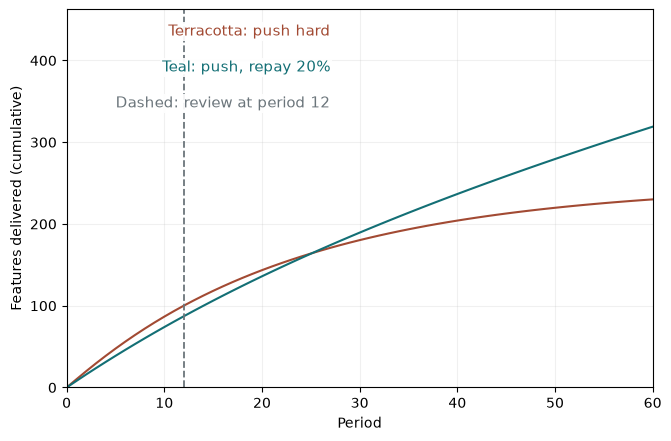

- **Review at period:** 12
- **Push hard, features:** 100.1
- **Repay 20%, features:** 87.2
- **Repaying minus push hard:** (-12.9)
- **Debt under push hard:** 50.1

At period 12: 87.2 - 100.1 = (-12.9) features for the repaying policy. The larger total over the smaller is 100.1 / 87.2 = 1.148. At this review push hard looks better, and a short window would confirm it.

In [5]:
show(review_window(review_period=12, repayment_share=0.2))

**Use the idea.** Ask what horizon a policy comparison was scored on before accepting it, and what the two policies look like one review later.

**Where the conclusion applies.** Constant pressure, the chapter's drag and defect rates, and cumulative features as the score. A short-lived codebase is the case where the short window gives the right answer.

*Constructed example: the chapter's two policies, recomputed with the chapter's run function.*

Every setting the interactive reader offers for this demonstration:

In [6]:
sweep(review_window, [('review_period', [12, 24, 48, 60]), ('repayment_share', [0.2, 0.35])])

- **review_period = 12, repayment_share = 0.2**: Review at period 12; Push hard, features 100.1; Repay 20%, features 87.2; Repaying minus push hard (-12.9); Debt under push hard 50.1
- **review_period = 12, repayment_share = 0.35**: Review at period 12; Push hard, features 100.1; Repay 35%, features 75.8; Repaying minus push hard (-24.3); Debt under push hard 50.1
- **review_period = 24, repayment_share = 0.2**: Review at period 24; Push hard, features 160.1; Repay 20%, features 158.2; Repaying minus push hard (-1.9); Debt under push hard 80.1
- **review_period = 24, repayment_share = 0.35**: Review at period 24; Push hard, features 160.1; Repay 35%, features 151.1; Repaying minus push hard (-9.0); Debt under push hard 80.1
- **review_period = 48, repayment_share = 0.2**: Review at period 48; Push hard, features 217.2; Repay 20%, features 271.2; Repaying minus push hard 54.0; Debt under push hard 108.6
- **review_period = 48, repayment_share = 0.35**: Review at period 48; Push hard, features 217.2; Repay 35%, features 301.8; Repaying minus push hard 84.6; Debt under push hard 108.6
- **review_period = 60, repayment_share = 0.2**: Review at period 60; Push hard, features 230.1; Repay 20%, features 319.0; Repaying minus push hard 88.9; Debt under push hard 115.0
- **review_period = 60, repayment_share = 0.35**: Review at period 60; Push hard, features 230.1; Repay 35%, features 377.1; Repaying minus push hard 147.0; Debt under push hard 115.0

## 2. Capacity is not what the plan says

*How much of the nominal capacity exists once debt drag and morale are subtracted?*

Drag takes the drag coefficient times the debt off nominal capacity, then morale scales the remainder. Debt only grows under push hard, so the gap widens with every period.

    drag = policy.drag * state.debt
    return max(0.0, (policy.capacity - drag) * state.morale)

**Symbols and inputs.** Nominal capacity is 10 engineer-weeks per period. Debt is shortcuts taken and not repaid. The drag coefficient is capacity lost per unit of debt. Morale scales what is left.

**Predict first.** After 60 periods of pushing hard, is available capacity closer to 10 or to 6?

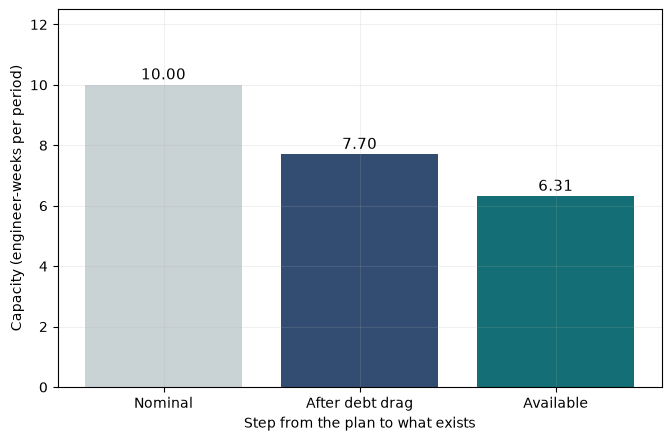

- **Debt carried:** 115.0
- **Morale:** 0.82
- **Drag coefficient:** 0.020
- **Available capacity:** 6.31
- **Plan over reality:** 1.58

Drag = 0.020 x 115.0 = 2.30. Available = max(0, (10.0 - 2.30) x 0.8198) = 6.31. Plan over reality = 10.0 / 6.31 = 1.58. A plan built on nominal capacity assumes 1.58 times what exists.

In [7]:
show(capacity_gap(situation='after a year', drag=0.02))

**Use the idea.** Compare the capacity a delivery plan assumes with the capacity measured over the last quarter.

**Where the conclusion applies.** The states are those of the push-hard run. Debt and morale are proxies in practice, so the exact available figure is an estimate; the direction of the gap is the claim.

*Constructed example: states from the chapter's push-hard run, recomputed with the chapter's available_capacity function.*

Every setting the interactive reader offers for this demonstration:

In [8]:
sweep(capacity_gap, [('situation', ['fresh', 'after a quarter', 'after a year']), ('drag', [0.01, 0.02])])

- **situation = fresh, drag = 0.01**: Debt carried 0.0; Morale 1.00; Drag coefficient 0.010; Available capacity 10.00; Plan over reality 1.00
- **situation = fresh, drag = 0.02**: Debt carried 0.0; Morale 1.00; Drag coefficient 0.020; Available capacity 10.00; Plan over reality 1.00
- **situation = after a quarter, drag = 0.01**: Debt carried 50.1; Morale 0.95; Drag coefficient 0.010; Available capacity 9.01; Plan over reality 1.11
- **situation = after a quarter, drag = 0.02**: Debt carried 50.1; Morale 0.95; Drag coefficient 0.020; Available capacity 8.54; Plan over reality 1.17
- **situation = after a year, drag = 0.01**: Debt carried 115.0; Morale 0.82; Drag coefficient 0.010; Available capacity 7.26; Plan over reality 1.38
- **situation = after a year, drag = 0.02**: Debt carried 115.0; Morale 0.82; Drag coefficient 0.020; Available capacity 6.31; Plan over reality 1.58

## 3. Rework share moves before delivery does

*Which number warns first, features delivered or the share of capacity spent on rework?*

Debt surfaces defects in proportion to itself. Each defect fixed takes 0.6 engineer-weeks from delivery, so the rework share climbs from the first periods, and a standing repayment share slows the climb.

    return max(0.0, (policy.capacity - drag) * state.morale)

**Symbols and inputs.** Rework share is capacity spent fixing defects divided by usable capacity. Each defect fixed costs 0.6 engineer-weeks. Repayment share is held back before delivery or rework.

**Predict first.** With no repayment, is the rework share in period 6 above or below 10 percent?

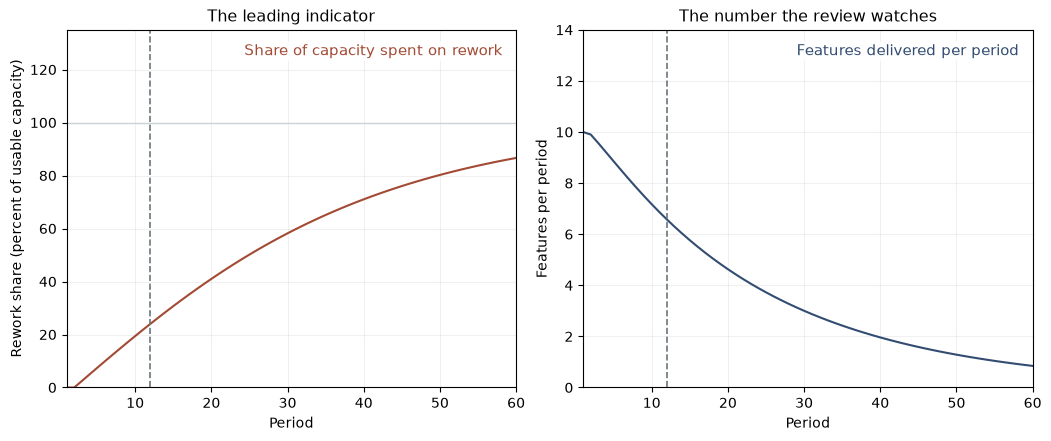

- **Repayment share:** 0.00
- **Period read:** 12
- **Usable capacity:** 8.65
- **Rework share:** 24.0 percent
- **Features delivered that period:** 6.57

In period 12 the team starts with 3.466 open defects and 8.654 usable capacity. After repaying 0.00 x 8.654 = 0.000, it fixes min(3.466, 8.654 / 0.6) = 3.466 defects, spending 3.466 x 0.6 = 2.080 on rework. Rework share = 2.080 / 8.654 = 0.240, which is 24.0 percent.

In [9]:
show(rework_signal(repayment_share=0.0, period=12))

**Use the idea.** Add a rework category to how work is tracked and plot its share beside delivery volume.

**Where the conclusion applies.** Rework is booked honestly. In many teams it is booked against the feature it belongs to, which hides this signal.

*Constructed example: the chapter's push-hard and repaying runs, rework share rebuilt from the chapter's step rule.*

Every setting the interactive reader offers for this demonstration:

In [10]:
sweep(rework_signal, [('repayment_share', [0.0, 0.2]), ('period', [6, 12, 26, 60])])

- **repayment_share = 0.0, period = 6**: Repayment share 0.00; Period read 6; Usable capacity 9.43; Rework share 9.8 percent; Features delivered that period 8.50
- **repayment_share = 0.0, period = 12**: Repayment share 0.00; Period read 12; Usable capacity 8.65; Rework share 24.0 percent; Features delivered that period 6.57
- **repayment_share = 0.0, period = 26**: Repayment share 0.00; Period read 26; Usable capacity 7.41; Rework share 51.9 percent; Features delivered that period 3.57
- **repayment_share = 0.0, period = 60**: Repayment share 0.00; Period read 60; Usable capacity 6.33; Rework share 86.6 percent; Features delivered that period 0.85
- **repayment_share = 0.2, period = 6**: Repayment share 0.20; Period read 6; Usable capacity 9.71; Rework share 4.8 percent; Features delivered that period 7.31
- **repayment_share = 0.2, period = 12**: Repayment share 0.20; Period read 12; Usable capacity 9.38; Rework share 10.0 percent; Features delivered that period 6.57
- **repayment_share = 0.2, period = 26**: Repayment share 0.20; Period read 26; Usable capacity 8.79; Rework share 19.7 percent; Features delivered that period 5.30
- **repayment_share = 0.2, period = 60**: Repayment share 0.20; Period read 60; Usable capacity 8.12; Rework share 32.7 percent; Features delivered that period 3.84

## 4. Test the conclusion against the proxy's range

*Does the repayment conclusion survive not knowing the drag coefficient?*

A larger drag makes debt more costly sooner, so the repaying policy overtakes earlier. At a short horizon and a small drag the lead can stay with push hard.

    drag = policy.drag * state.debt

**Symbols and inputs.** The drag coefficient converts debt into lost capacity and cannot be read from a register. Debt is shown as a direction, not a level. The horizon is the period at which features are compared.

**Predict first.** At period 60, does the repaying policy lead for every drag value from 0.005 to 0.03?

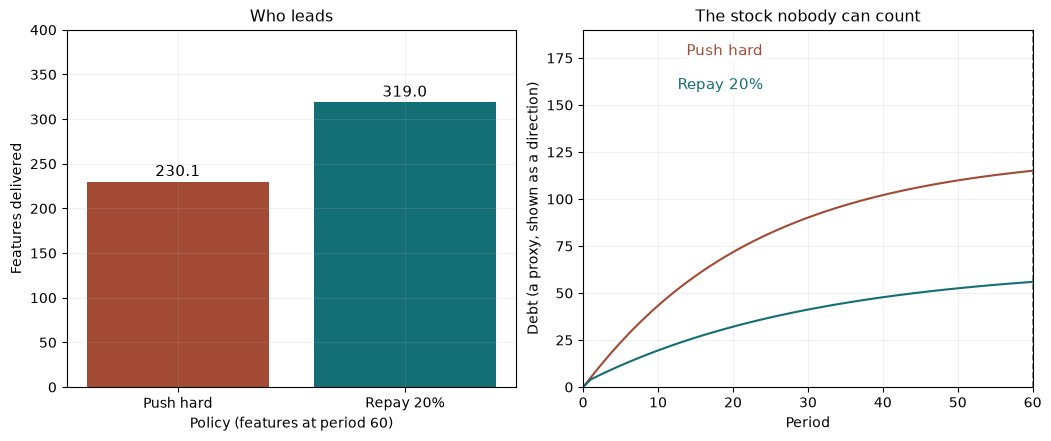

- **Drag coefficient:** 0.020
- **Horizon (periods):** 60
- **Push hard, features:** 230.1
- **Repay 20%, features:** 319.0
- **Repaying minus push hard:** 88.9

With drag 0.020 at period 60: 319.0 - 230.1 = 88.9 features. Debt under push hard is 115.0, so the drag is 0.020 x 115.0 = 2.30 engineer-weeks. Repaying leads at this horizon.

In [11]:
show(drag_range(drag=0.02, horizon=60))

**Use the idea.** State the recommendation with the range of the unmeasured value, and say whether the range changes the decision.

**Where the conclusion applies.** Drag is held constant over time and across the codebase, which real systems do not do. The conclusion also depends on the shortcut and defect rates being as set.

*Constructed example: drag values defined for this reader around the chapter's 0.02, run with the chapter's run function.*

Every setting the interactive reader offers for this demonstration:

In [12]:
sweep(drag_range, [('drag', [0.005, 0.01, 0.02, 0.03]), ('horizon', [24, 60])])

- **drag = 0.005, horizon = 24**: Drag coefficient 0.005; Horizon (periods) 24; Push hard, features 172.3; Repay 20%, features 163.4; Repaying minus push hard (-8.9)
- **drag = 0.005, horizon = 60**: Drag coefficient 0.005; Horizon (periods) 60; Push hard, features 262.1; Repay 20%, features 337.9; Repaying minus push hard 75.8
- **drag = 0.01, horizon = 24**: Drag coefficient 0.010; Horizon (periods) 24; Push hard, features 168.1; Repay 20%, features 161.7; Repaying minus push hard (-6.4)
- **drag = 0.01, horizon = 60**: Drag coefficient 0.010; Horizon (periods) 60; Push hard, features 250.8; Repay 20%, features 331.4; Repaying minus push hard 80.6
- **drag = 0.02, horizon = 24**: Drag coefficient 0.020; Horizon (periods) 24; Push hard, features 160.1; Repay 20%, features 158.2; Repaying minus push hard (-1.9)
- **drag = 0.02, horizon = 60**: Drag coefficient 0.020; Horizon (periods) 60; Push hard, features 230.1; Repay 20%, features 319.0; Repaying minus push hard 88.9
- **drag = 0.03, horizon = 24**: Drag coefficient 0.030; Horizon (periods) 24; Push hard, features 152.7; Repay 20%, features 154.9; Repaying minus push hard 2.2
- **drag = 0.03, horizon = 60**: Drag coefficient 0.030; Horizon (periods) 60; Push hard, features 211.7; Repay 20%, features 307.2; Repaying minus push hard 95.5

## Exercises

Try each before opening the answer. The settings above let you check the numbers.

### Exercise 1

At period 60, how many times more features has repay 20 percent delivered than push hard?

<details><summary>Answer</summary>

319.0 / 230.1 = 1.39, about 39 percent more.

</details>

### Exercise 2

With debt 50 and drag 0.02, what is the capacity after drag, before morale?

<details><summary>Answer</summary>

10 - 0.02 x 50 = 10 - 1.0 = 9.0 engineer-weeks.

</details>

### Exercise 3

With 4 open defects and 9 units to deliver, what is the rework share of 9 usable units?

<details><summary>Answer</summary>

fixing = min(4, 9 / 0.6) = 4 defects, rework = 4 x 0.6 = 2.4, share = 2.4 / 9 = 0.27.

</details>

---

From *Systems Thinking with AI* by Jason Karpeles. Copyright Jason Karpeles. All rights reserved.

Interactive companion: https://karpeles.com/companions/systems-thinking-with-ai/